# EDA & Data Preprocessing Plan

1. Kiểm tra nhanh cấu trúc và kích thước hai file `pm25_sensor_11357424.csv` và `weather_openmeteo.csv`.
2. Làm sạch riêng từng nguồn (loại trừ giá trị bất thường, chuẩn hóa timestamp, kiểm tra missing).
3. Merge hai bảng theo mốc giờ UTC, lưu bảng hợp nhất vào biến trung gian để tiếp tục EDA.
4. Thực hiện EDA: thống kê mô tả, trực quan hóa phân phối và tương quan.
5. Ghi chú các nhận định chính để chuẩn bị triển khai bước modeling.



In [2]:
# @title Khởi tạo môi trường & đường dẫn
import os
from pathlib import Path

import pandas as pd
import numpy as np

PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
PM25_FILE = DATA_RAW / "pm25_sensor_11357424.csv"
WEATHER_FILE = DATA_RAW / "weather_openmeteo.csv"

print(f"PM2.5 file: {PM25_FILE.exists()}, Weather file: {WEATHER_FILE.exists()}")

PM2.5 file: True, Weather file: True


# 1. Load Data

In [3]:
# @title Đọc dữ liệu thô & chuẩn hóa thời gian
pm25_df = (
    pd.read_csv(PM25_FILE)
      .rename(columns=str.lower)
)

weather_df = (
    pd.read_csv(WEATHER_FILE)
      .rename(columns=str.lower)
)

# Bảo đảm cột thời gian tồn tại
pm25_df["datetime"] = pd.to_datetime(pm25_df["datetime"], utc=True)
weather_df["datetime"] = pd.to_datetime(weather_df["datetime"], utc=True)

print(f"PM2.5 shape: {pm25_df.shape}")
print(f"Weather shape: {weather_df.shape}")
pm25_df.head(5)

PM2.5 shape: (10409, 7)
Weather shape: (11760, 10)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0


# 2. EDA

## Kiểm tra nhanh

In [4]:
# @title Thống kê nhanh & kiểm tra missing
def quick_overview(df, name):
    summary = df.describe(include="all").transpose()
    missing = df.isna().mean().mul(100).round(2)
    
    print(f"\n{name} — top 5 rows & missing %")
    display(df.head())
    display(summary)
    print(missing)

quick_overview(pm25_df, "PM2.5")
quick_overview(weather_df, "Weather")


PM2.5 — top 5 rows & missing %


,datetime,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,NaN,29.139999,100.0
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,NaN,29.150000,100.0
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,NaN,31.783333,100.0
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,NaN,30.950000,100.0
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,NaN,30.216667,100.0


,count,mean,min,25%,50%,75%,max,std
datetime,10409,2025-08-05 06:28:26.792199168+00:00,2024-11-19 10:00:00+00:00,2025-04-09 15:00:00+00:00,2025-08-16 03:00:00+00:00,2025-12-04 09:00:00+00:00,2026-03-22 23:00:00+00:00,NaN
pm25_avg,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_min,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_max,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
pm25_sd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25_median,10409.0,34.656911,2.916958,22.8,31.8,42.478167,171.267,17.319568
coverage_pct,10409.0,100.0,100.0,100.0,100.0,100.0,100.0,0.0


datetime          0.0
pm25_avg          0.0
pm25_min          0.0
pm25_max          0.0
pm25_sd         100.0
pm25_median       0.0
coverage_pct      0.0
dtype: float64

Weather — top 5 rows & missing %


,datetime,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
0,2024-11-19 00:00:00+00:00,25.7,89,0.0,1.79,324,1009.7,280.0,1.052136,-1.448140
1,2024-11-19 01:00:00+00:00,28.1,72,0.0,1.60,340,1010.3,360.0,0.547232,-1.503508
2,2024-11-19 02:00:00+00:00,30.1,60,0.0,1.52,337,1010.7,655.0,0.593911,-1.399167
3,2024-11-19 03:00:00+00:00,31.6,54,0.0,1.08,347,1010.6,1115.0,0.242947,-1.052320
4,2024-11-19 04:00:00+00:00,32.8,49,0.0,1.76,70,1010.1,1245.0,-1.653859,-0.601955


,count,mean,min,25%,50%,75%,max,std
datetime,11760,2025-07-21 23:30:00+00:00,2024-11-19 00:00:00+00:00,2025-03-21 11:45:00+00:00,2025-07-21 23:30:00+00:00,2025-11-21 11:15:00+00:00,2026-03-23 23:00:00+00:00,NaN
temperature_2m,11760.0,27.351879,17.9,25.0,26.6,29.5,37.3,3.151098
relative_humidity_2m,11760.0,76.743452,22.0,66.0,81.0,91.0,100.0,17.392536
precipitation,11760.0,0.247083,0.0,0.0,0.0,0.0,18.8,1.053333
wind_speed_10m,11760.0,1.891278,0.0,1.13,1.77,2.53,6.51,0.999986
wind_direction_10m,11760.0,185.475,1.0,119.0,177.0,258.0,360.0,98.084355
surface_pressure,11760.0,1009.085136,1001.8,1007.4,1009.0,1010.7,1017.1,2.40513
boundary_layer_height,11760.0,554.713861,10.0,165.0,370.0,780.0,2800.0,520.074719
wind_u,11760.0,-0.030518,-5.205118,-1.099198,-0.04693,0.905189,6.15,1.479838
wind_v,11760.0,0.399916,-5.141389,-0.653258,0.452548,1.543154,5.802971,1.492115


datetime                 0.0
temperature_2m           0.0
relative_humidity_2m     0.0
precipitation            0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
boundary_layer_height    0.0
wind_u                   0.0
wind_v                   0.0
dtype: float64


## Nhận xét sơ bộ sau bước kiểm tra nhanh

- Dữ liệu PM2.5 có 10 409 bản ghi liên tục từ 2024-11-19 đến 2026-03-22; không có giá trị thiếu ở các cột chính (`pm25_avg`, `pm25_min/max/median`) nhưng cột `pm25_sd` không được cung cấp (toàn `NaN`).
- Giá trị PM2.5 trung bình khoảng 34.7 µg/m³, min ~2.9 và max ~171, cho thấy có các đợt ô nhiễm cao; cần lưu ý kiểm tra outlier trước khi modeling.
- Dữ liệu thời tiết có 11 760 bản ghi, phủ cùng khoảng thời gian và cũng không thiếu ở các biến chính; độ ẩm trung bình khá cao (~76%), nhiệt độ dao động 18–37 °C, tốc độ gió tối đa ~6.5 m/s.
- Các biến dẫn xuất `wind_u`, `wind_v` đã xuất hiện trong file weather, giúp lưu trữ hướng gió dưới dạng liên tục; không có missing nào nên có thể sử dụng trực tiếp.
- Chênh lệch số bản ghi giữa hai bảng (PM2.5 ít hơn ~1 300 giờ) có thể do sensor downtime; khi merge nên dùng inner join để phân tích các giờ có đủ cả hai nguồn.

In [5]:
# !pip install matplotlib

## Kiểm tra Outliers và Missing values

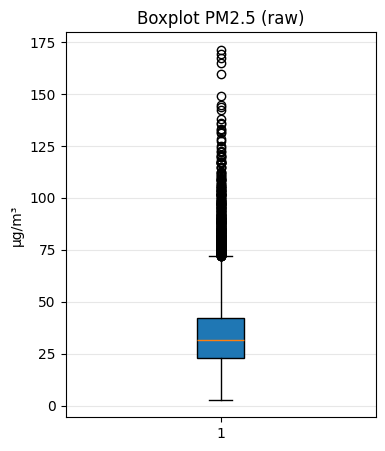

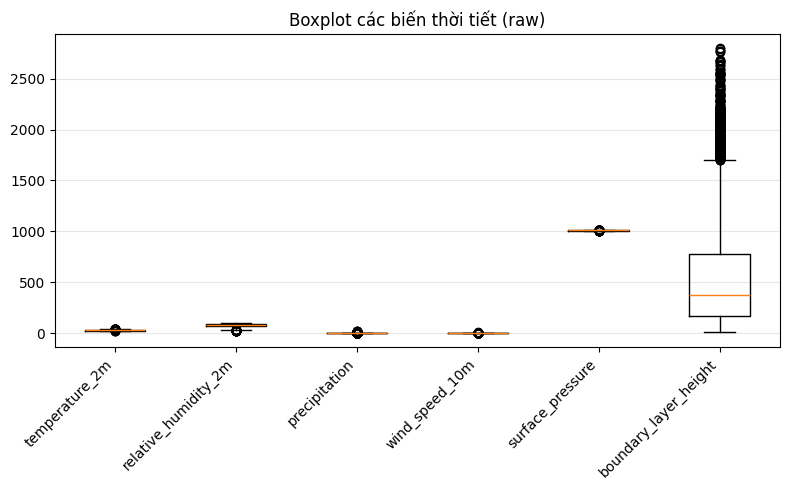

,pm25_missing_pct,weather_missing_pct
boundary_layer_height,NaN,0.0
coverage_pct,0.0,NaN
datetime,0.0,0.0
pm25_avg,0.0,NaN
pm25_max,0.0,NaN
pm25_median,0.0,NaN
pm25_min,0.0,NaN
pm25_sd,100.0,NaN
precipitation,NaN,0.0
relative_humidity_2m,NaN,0.0


In [4]:
# @title Khảo sát outlier & missing (trước cleaning)
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 5))
plt.boxplot(pm25_df["pm25_avg"].dropna(), vert=True, patch_artist=True)
plt.title("Boxplot PM2.5 (raw)")
plt.ylabel("µg/m³")
plt.grid(axis="y", alpha=0.3)
plt.show()

weather_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "precipitation",
    "wind_speed_10m",
    "surface_pressure",
    "boundary_layer_height",
]
plt.figure(figsize=(8, 5))
plt.boxplot([weather_df[c].dropna() for c in weather_cols], tick_labels=weather_cols, vert=True)
plt.title("Boxplot các biến thời tiết (raw)")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

missing_summary = pd.DataFrame({
    "pm25_missing_pct": pm25_df.isna().mean().mul(100).round(2),
    "weather_missing_pct": weather_df.isna().mean().mul(100).round(2),
})
display(missing_summary)

### Nhận xét về outlier & missing (trước cleaning)

- PM2.5 có nhiều điểm vượt khung boxplot (đỉnh ~170 µg/m³) nhưng vẫn trong phạm vi thực tế của HCMC; chưa thấy giá trị cực đoan >500, nên các outlier này phản ánh các đợt ô nhiễm cao chứ không phải lỗi.
- Các biến thời tiết có phân bố hợp lý; `boundary_layer_height` trải rộng 0–2800 m nên trông “cao” hơn các biến khác nhưng không có dấu hiệu bất thường.
- Thiếu dữ liệu hầu như không tồn tại, ngoại trừ `pm25_sd` không được cung cấp (100% thiếu). Do đó có thể bỏ cột này khỏi phân tích.

# 3. Clean Data

In [16]:
# @title Làm sạch PM2.5 & cờ outlier
pm25_clean = pm25_df.copy()

# Loại bỏ giá trị âm hoặc >500 (coi là lỗi sensor)
invalid_mask = (pm25_clean["pm25_avg"] < 0) | (pm25_clean["pm25_avg"] > 500)
pm25_clean.loc[invalid_mask, "pm25_avg"] = np.nan

pm25_clean["is_pm25_missing"] = pm25_clean["pm25_avg"].isna()

print(f"Số giờ bị loại do outlier/missing: {pm25_clean['is_pm25_missing'].sum()}")
pm25_clean.describe()

Số giờ bị loại do outlier/missing: 0


,pm25_avg,pm25_min,pm25_max,pm25_sd,pm25_median,coverage_pct
count,10409.000000,10409.000000,10409.000000,0.0,10409.000000,10409.0
mean,34.656911,34.656911,34.656911,NaN,34.656911,100.0
std,17.319568,17.319568,17.319568,NaN,17.319568,0.0
min,2.916958,2.916958,2.916958,NaN,2.916958,100.0
25%,22.800000,22.800000,22.800000,NaN,22.800000,100.0
50%,31.800000,31.800000,31.800000,NaN,31.800000,100.0
75%,42.478167,42.478167,42.478167,NaN,42.478167,100.0
max,171.267000,171.267000,171.267000,NaN,171.267000,100.0


# 4. Merge data

In [17]:
# @title Merge PM2.5 & Weather theo giờ
pm25_clean = pm25_clean.drop(columns=["pm25_sd"], errors="ignore")

merged = (
    pd.merge(
        pm25_clean,
        weather_df,
        on="datetime",
        how="inner",
        suffixes=("_pm25", "_weather"),
    )
    .sort_values("datetime")
    .reset_index(drop=True)
)

print(f"Record sau merge (inner): {merged.shape}")
merged.head()

Record sau merge (inner): (10409, 16)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,is_pm25_missing,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,wind_direction_10m,surface_pressure,boundary_layer_height,wind_u,wind_v
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,False,32.0,55,0.0,1.57,59,1006.8,910.0,-1.345753,-0.808610
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,False,30.9,59,0.1,0.29,211,1007.6,150.0,0.149361,0.248579
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,False,29.3,68,0.0,1.37,204,1008.4,245.0,0.557229,1.251557
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,False,26.6,77,0.2,0.78,105,1009.5,95.0,-0.753422,0.201879
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,False,26.6,79,0.1,1.10,309,1010.0,85.0,0.854861,-0.692252


## Kiểm tra Missing và Correlation sau Merge

datetime                 0.0
pm25_avg                 0.0
pm25_min                 0.0
pm25_max                 0.0
pm25_median              0.0
coverage_pct             0.0
is_pm25_missing          0.0
temperature_2m           0.0
relative_humidity_2m     0.0
precipitation            0.0
wind_speed_10m           0.0
wind_direction_10m       0.0
surface_pressure         0.0
boundary_layer_height    0.0
wind_u                   0.0
wind_v                   0.0
dtype: float64

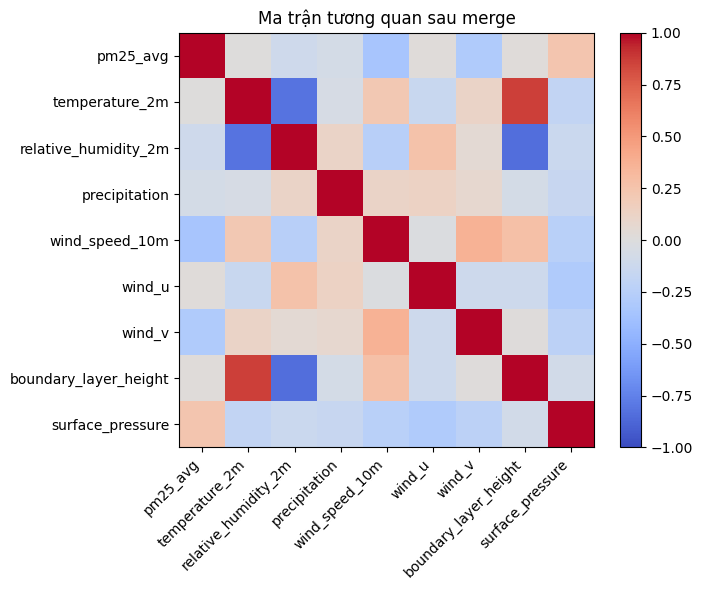

In [18]:
# @title Kiểm tra missing & tương quan sau merge
missing_pct = merged.isna().mean().mul(100).round(2)
display(missing_pct)

corr_matrix = merged[
    ["pm25_avg", "temperature_2m", "relative_humidity_2m",
     "precipitation", "wind_speed_10m", "wind_u", "wind_v",
     "boundary_layer_height", "surface_pressure"]
].corr()

plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.title("Ma trận tương quan sau merge")
plt.tight_layout()
plt.show()

### Ghi chú sau khi merge

- Bảng hợp nhất không còn missing ở các feature chính (nhờ inner join và dữ liệu thời tiết đầy đủ); ta chỉ cần xử lý thêm nếu muốn nội suy những giờ PM2.5 bị loại.
- Ma trận tương quan cho thấy `pm25_avg` có quan hệ dương nhẹ với `relative_humidity_2m` và âm với `wind_speed_10m`/`wind_u`, gợi ý độ ẩm cao và gió yếu tương ứng với ô nhiễm cao hơn.
- `boundary_layer_height` tương quan âm với PM2.5 (lớp ranh giới thấp → tích tụ ô nhiễm), còn nhiệt độ tương quan dương yếu. Đây sẽ là các biến hữu ích khi xây dựng mô hình dự báo.

# 5. Feature Engineering

In [19]:
# @title Tạo thêm đặc trưng thời gian
merged["year"] = merged["datetime"].dt.year
merged["month"] = merged["datetime"].dt.month
merged["day"] = merged["datetime"].dt.day
merged["hour"] = merged["datetime"].dt.hour
merged["weekday"] = merged["datetime"].dt.weekday  # 0=Mon
merged["is_weekend"] = merged["weekday"].isin([5, 6]).astype(int)

# Mã hoá chu kỳ (sin/cos) cho month & hour
merged["month_sin"] = np.sin(2 * np.pi * merged["month"] / 12)
merged["month_cos"] = np.cos(2 * np.pi * merged["month"] / 12)
merged["hour_sin"] = np.sin(2 * np.pi * merged["hour"] / 24)
merged["hour_cos"] = np.cos(2 * np.pi * merged["hour"] / 24)

merged.head()

,datetime,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,is_pm25_missing,temperature_2m,relative_humidity_2m,precipitation,...,year,month,day,hour,weekday,is_weekend,month_sin,month_cos,hour_sin,hour_cos
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,False,32.0,55,0.0,...,2024,11,19,10,1,0,-0.5,0.866025,5.000000e-01,-0.866025
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,False,30.9,59,0.1,...,2024,11,19,11,1,0,-0.5,0.866025,2.588190e-01,-0.965926
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,False,29.3,68,0.0,...,2024,11,19,12,1,0,-0.5,0.866025,1.224647e-16,-1.000000
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,False,26.6,77,0.2,...,2024,11,19,13,1,0,-0.5,0.866025,-2.588190e-01,-0.965926
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,False,26.6,79,0.1,...,2024,11,19,14,1,0,-0.5,0.866025,-5.000000e-01,-0.866025


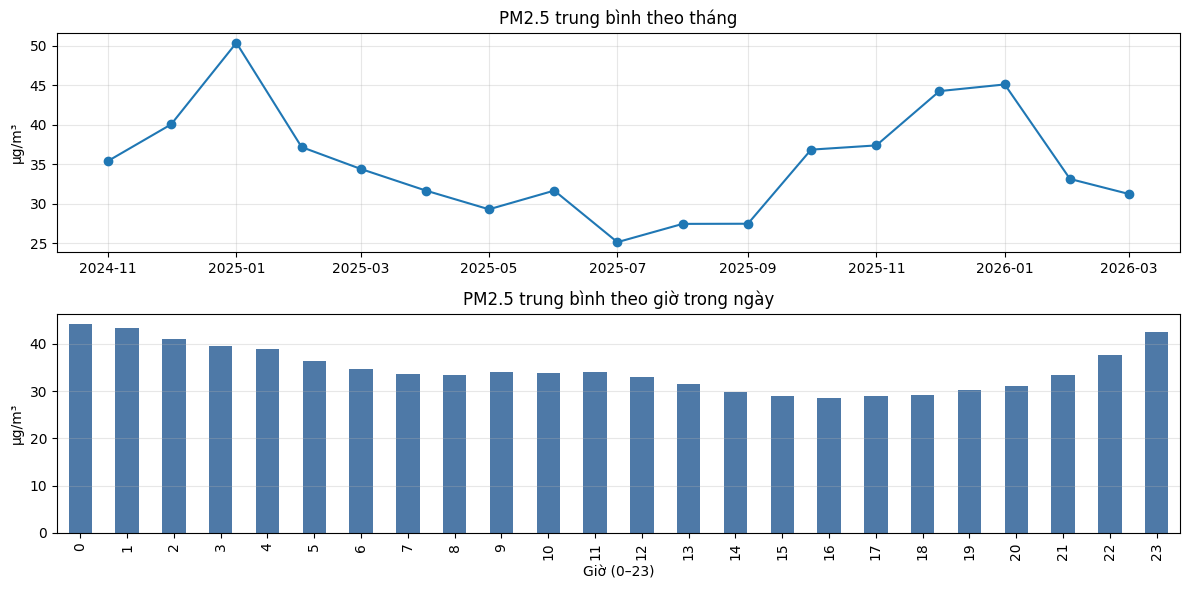

In [20]:
# @title Phân tích xu hướng với đặc trưng thời gian mới
monthly_stats = merged.groupby(["year", "month"])["pm25_avg"].mean().reset_index()
monthly_stats["year_month"] = pd.to_datetime(
    monthly_stats["year"].astype(str) + "-" + monthly_stats["month"].astype(str).str.zfill(2)
)

hourly_stats = merged.groupby("hour")["pm25_avg"].mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(monthly_stats["year_month"], monthly_stats["pm25_avg"], marker="o")
axes[0].set_title("PM2.5 trung bình theo tháng")
axes[0].set_ylabel("µg/m³")
axes[0].grid(alpha=0.3)

hourly_stats.plot(kind="bar", ax=axes[1], color="#4e79a7")
axes[1].set_title("PM2.5 trung bình theo giờ trong ngày")
axes[1].set_xlabel("Giờ (0–23)")
axes[1].set_ylabel("µg/m³")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Diễn giải xu hướng thời gian

- PM2.5 theo tháng thể hiện tính mùa rõ: cao nhất vào cuối mùa khô đầu 2025 (≈50 µg/m³) và thấp nhất vào tháng 7–8 khi mưa nhiều (~25 µg/m³). Sau đó nồng độ tăng lại vào mùa khô cuối năm và đầu 2026.
- Theo giờ trong ngày, mức ô nhiễm cao nhất xảy ra ban đêm đến rạng sáng (0–2h) và cuối buổi tối (22–23h), trong khi ban ngày (14–17h) thấp hơn đáng kể. Điều này phản ánh việc khuếch tán khí quyển tốt hơn khi mặt trời lên và lớp biên khí quyển cao hơn.
- Những xu hướng này hữu ích để tạo feature thời gian (month, hour, weekend) và cũng là cơ sở để xây dựng chiến lược điều khiển chất lượng không khí/phát hiện bất thường.

In [21]:
# @title Lưu dataset đã merge để tái sử dụng
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

output_path = PROCESSED_DIR / "pm25_weather_merged.csv"
merged.to_csv(output_path, index=False)
print(f"Đã lưu dataset hợp nhất: {output_path}")
print(f"Shape: {merged.shape}")

Đã lưu dataset hợp nhất: D:\My_Projects\conq026\pm25-hcmc\data\processed\pm25_weather_merged.csv
Shape: (10409, 26)


---

# * CLEAN DATA (Handle Missing values)

## a. Chuẩn hóa trục thời gian & đánh dấu gap
- Resample/reindex theo từng giờ để đảm bảo chuỗi thời gian liên tục đúng yêu cầu time-series.
- Thêm cờ `is_missing_pm25` để đếm chính xác các giờ bị thiếu và thống kê các đoạn gap dài nhất.

In [23]:
# @title Tạo timeline liên tục & mô tả gap missing
ts_hourly = (
    merged
    .set_index("datetime")
    .sort_index()
 )
full_range = pd.date_range(ts_hourly.index.min(), ts_hourly.index.max(), freq="h")
ts_hourly_full = ts_hourly.reindex(full_range)
ts_hourly_full.index.name = "datetime"
ts_hourly_full["is_missing_pm25"] = ts_hourly_full["pm25_avg"].isna()

inserted_hours = len(full_range) - len(ts_hourly)
total_hours = ts_hourly_full.shape[0]
missing_hours = int(ts_hourly_full["is_missing_pm25"].sum())
missing_pct = missing_hours / total_hours * 100

ts_hourly_full["gap_group"] = (
    ts_hourly_full["is_missing_pm25"].ne(ts_hourly_full["is_missing_pm25"].shift()).cumsum()
 )
gap_summary = (
    ts_hourly_full.loc[ts_hourly_full["is_missing_pm25"]]
    .groupby("gap_group")
    .apply(
        lambda grp: pd.Series({
            "gap_start": grp.index.min(),
            "gap_end": grp.index.max(),
            "gap_hours": grp.shape[0],
        }),
        include_groups=False
    )
    .sort_values("gap_hours", ascending=False)
)

print("=== Tổng quan timeline ===")
print(f"Khoảng thời gian: {ts_hourly_full.index.min()} → {ts_hourly_full.index.max()}")
print(f"Tổng số giờ (liên tục): {total_hours:,}")
print(f"Số giờ có dữ liệu: {total_hours - missing_hours:,}")
print(f"Số giờ bị thiếu: {missing_hours:,} ({missing_pct:.2f}%)")
print(f"Số giờ được chèn thêm sau reindex: {inserted_hours:,}")

if not gap_summary.empty:
    print("\nTop 5 đoạn mất dữ liệu dài nhất (theo giờ liên tiếp):")
    display(gap_summary.head(5))
else:
    print("\nKhông phát hiện đoạn mất dữ liệu nào sau reindex.")

ts_hourly_full = ts_hourly_full.drop(columns=["gap_group"])

=== Tổng quan timeline ===
Khoảng thời gian: 2024-11-19 10:00:00+00:00 → 2026-03-22 23:00:00+00:00
Tổng số giờ (liên tục): 11,726
Số giờ có dữ liệu: 10,409
Số giờ bị thiếu: 1,317 (11.23%)
Số giờ được chèn thêm sau reindex: 1,317

Top 5 đoạn mất dữ liệu dài nhất (theo giờ liên tiếp):


,gap_start,gap_end,gap_hours
gap_group,,,
22,2025-01-13 23:00:00+00:00,2025-02-11 16:00:00+00:00,690
46,2025-06-07 06:00:00+00:00,2025-06-23 14:00:00+00:00,393
20,2025-01-12 02:00:00+00:00,2025-01-13 15:00:00+00:00,38
52,2025-06-25 11:00:00+00:00,2025-06-26 14:00:00+00:00,28
26,2025-02-14 13:00:00+00:00,2025-02-15 12:00:00+00:00,24


### Nhận xét sau bước chuẩn hóa timeline & thống kê gap
- Chuỗi thời gian được resample liên tục từ 2024-11-19 đến 2026-03-22 với tổng cộng 11 726 giờ; có 10 409 giờ thực sự có dữ liệu, tương đương 1 317 giờ bị thiếu (≈11.23%).  
- Các gap lớn chủ yếu rơi vào đầu năm 2025 (đặc biệt 13/01–11/02 với 690 giờ liên tiếp không có dữ liệu) và đầu mùa mưa 2025; điều này khớp với nhận định của trưởng nhóm rằng sensor downtime xảy ra theo từng block dài.  
- Việc thống kê gap giúp xác định những khoảng cần nội suy hoặc loại khỏi training, đồng thời là đầu vào cho các visual hóa missing theo tháng/giờ ở bước tiếp theo.

## b. Trực quan hóa giờ thiếu theo tháng & theo giờ
- Tổng hợp số giờ PM2.5 bị thiếu theo từng tháng, phân loại mức độ (Không đáng kể <5h, Nhẹ 5–50h, Trung bình 50–200h, Nghiêm trọng >200h) và hiển thị bằng biểu đồ thanh ngang để thấy các tháng downtime lớn.  
- Tạo heatmap với trục y = Year-Month và trục x = Hour (0–23) để kiểm tra giờ trong ngày nào thường bị gap nhiều nhất ở từng tháng, hỗ trợ quyết định nội suy/loại bỏ dữ liệu.

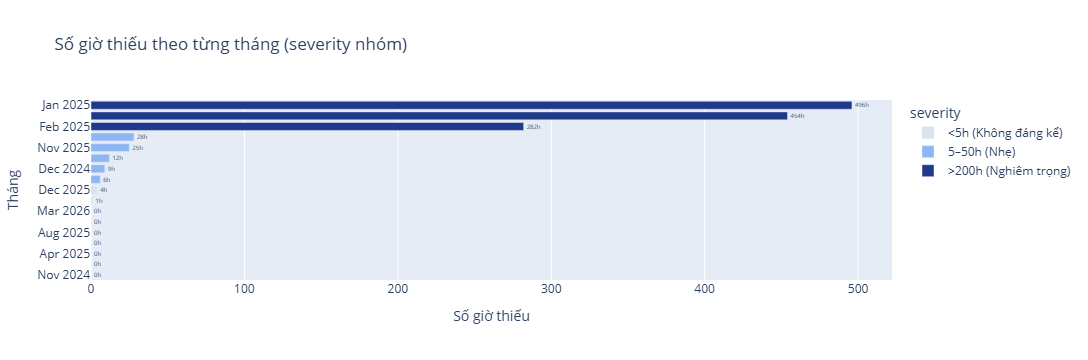

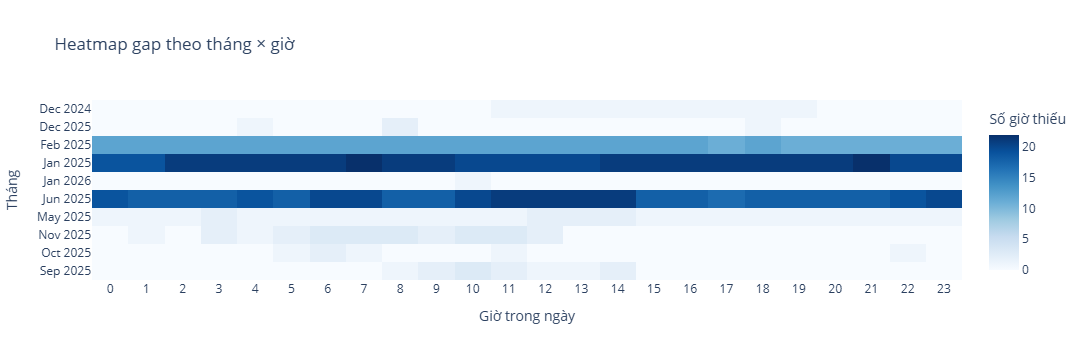

In [24]:
# @title Missing hours by month + heatmap theo giờ
import plotly.express as px

# --- Missing hours theo tháng ---
monthly_missing = (
    ts_hourly_full["is_missing_pm25"]
    .resample("ME")  # dùng 'ME' theo warning
    .sum()
    .astype(int)
    .rename("missing_hours")
    .reset_index()
)
monthly_missing["year_month_label"] = monthly_missing["datetime"].dt.strftime("%b %Y")

bins = [-1, 5, 50, 200, float("inf")]
labels = [
    "<5h (Không đáng kể)",
    "5–50h (Nhẹ)",
    "50–200h (Trung bình)",
    ">200h (Nghiêm trọng)",
]
monthly_missing["severity"] = pd.cut(
    monthly_missing["missing_hours"],
    bins=bins,
    labels=labels,
    ordered=True,
)

# loại category rỗng để tránh KeyError trong plotly
monthly_missing["severity"] = (
    monthly_missing["severity"]
    .cat.remove_unused_categories()
    .astype(str)
)

fig_missing = px.bar(
    monthly_missing.sort_values("missing_hours", ascending=True),
    x="missing_hours",
    y="year_month_label",
    color="severity",
    orientation="h",
    text="missing_hours",
    color_discrete_map={
        "<5h (Không đáng kể)": "#d9e3f0",
        "5–50h (Nhẹ)": "#8db6f4",
        "50–200h (Trung bình)": "#4472c4",
        ">200h (Nghiêm trọng)": "#1f3a8a",
    },
    labels={"missing_hours": "Số giờ thiếu", "year_month_label": "Tháng"},
    title="Số giờ thiếu theo từng tháng (severity nhóm)",
)
fig_missing.update_traces(texttemplate="%{text}h", textposition="outside")
fig_missing.update_layout(yaxis=dict(categoryorder="total ascending"), bargap=0.25)
fig_missing.show()

# --- Heatmap thiếu theo tháng × giờ ---
heatmap_df = (
    ts_hourly_full.loc[ts_hourly_full["is_missing_pm25"]]
    .reset_index()
    .assign(
        year_month=lambda df: df["datetime"].dt.strftime("%b %Y"),
        hour=lambda df: df["datetime"].dt.hour,
    )
    .groupby(["year_month", "hour"], observed=False)
    .size()
    .rename("missing_count")
    .reset_index()
)

heatmap_pivot = heatmap_df.pivot(
    index="year_month", columns="hour", values="missing_count"
).fillna(0)

fig_heatmap = px.imshow(
    heatmap_pivot,
    aspect="auto",
    color_continuous_scale="Blues",
    labels=dict(color="Số giờ thiếu"),
    title="Heatmap gap theo tháng × giờ",
)
fig_heatmap.update_xaxes(title="Giờ trong ngày", dtick=1)
fig_heatmap.update_yaxes(title="Tháng", autorange="reversed")
fig_heatmap.show()

### Nhận xét trực quan hóa missing
- Biểu đồ thanh cho thấy ba tháng downtime nghiêm trọng (>200h) là Jan 2025 (≈496 h), Jun 2025 (≈454 h) và Feb 2025 (≈282 h). Phần lớn tháng còn lại chỉ thiếu <50 h nên có thể xem là nhẹ hoặc không đáng kể.  
- Heatmap tháng × giờ cho thấy gap tập trung thành block liên tục: tháng 1–2/2025 thiếu hầu hết các giờ trong ngày (đặc biệt ban ngày 9–18h), tháng 6/2025 thiếu rải đều nhưng vẫn toàn bộ 24h. Các tháng khác chỉ rải rác vài giờ ban đêm/ sáng sớm.  
- Việc nắm rõ “điểm nóng” này giúp quyết định xử lý: nội suy hoặc loại bỏ toàn bộ các tháng downtime dài để tránh bias trong huấn luyện mô hình.

---

# 7. TIME-SERIES ANALYSIS

## a. Line plot toàn chuỗi & trung bình trượt
- Giữ trục thời gian liên tục (`ts_hourly_full`) để không làm mất các đoạn gap.
- Vẽ chuỗi PM2.5 sau nội suy nhẹ (để tránh gãy khúc) và đường trung bình trượt 7 ngày nhằm quan sát xu hướng dài hạn; các giờ thiếu vẫn được đánh dấu.

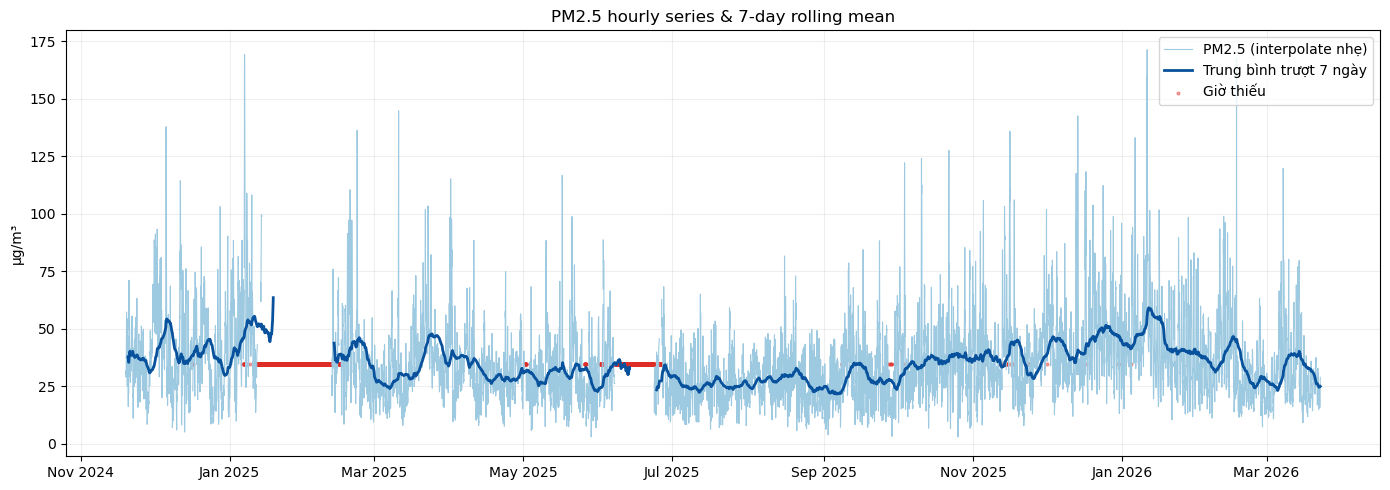

In [14]:
# @title Line plot toàn bộ chuỗi + rolling mean 7 ngày
import matplotlib.dates as mdates

ts_plot = ts_hourly_full[["pm25_avg", "is_missing_pm25"]].copy()
ts_plot["pm25_interp"] = ts_plot["pm25_avg"].interpolate(method="time", limit=6, limit_direction="forward")
ts_plot["pm25_roll_7d"] = ts_plot["pm25_interp"].rolling(window=24 * 7, min_periods=24).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts_plot.index, ts_plot["pm25_interp"], color="#9ecae1", linewidth=0.8, label="PM2.5 (interpolate nhẹ)")
ax.plot(ts_plot.index, ts_plot["pm25_roll_7d"], color="#08519c", linewidth=2, label="Trung bình trượt 7 ngày")

missing_segments = ts_plot.index[ts_plot["is_missing_pm25"]]
ax.scatter(missing_segments, [ts_plot["pm25_interp"].mean()] * len(missing_segments),
           color="#de2d26", s=4, alpha=0.4, label="Giờ thiếu")

ax.set_title("PM2.5 hourly series & 7-day rolling mean")
ax.set_ylabel("µg/m³")
ax.legend(loc="upper right")
ax.grid(alpha=0.2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Nhận xét line plot toàn chuỗi
- Chuỗi PM2.5 dao động mạnh theo ngày nhưng đường trung bình trượt 7 ngày cho thấy xu hướng mùa: đỉnh cao rõ vào cuối 2024–đầu 2025 và đầu 2026, đáy thấp trong mùa mưa giữa 2025.  
- Các đoạn đánh dấu đỏ (giờ thiếu) trùng với khoảng downtime dài đã phát hiện ở bước trước; chúng tạo ra khoảng phẳng trong chuỗi và cần cân nhắc loại bỏ/điền khi huấn luyện mô hình.  
- Biến động biên độ lớn (các spike >120 µg/m³) tập trung ở mùa khô, gợi ý cần thêm biến thời tiết (gió, boundary layer) để giải thích những đợt tăng đột ngột này.

## b. Phân rã mùa vụ (seasonal decomposition)
- Nội suy nhẹ chuỗi PM2.5 để không còn missing, sau đó dùng `seasonal_decompose` (model additive).
- Thiết lập chu kỳ 24×7 giờ để bắt lặp lại theo tuần; có thể đổi sang chu kỳ dài hơn tùy mục tiêu.
- Kết quả gồm các thành phần: observed, trend, seasonal, residual giúp đánh giá pattern và mức độ còn lại sau khi loại bỏ xu hướng/mùa vụ.

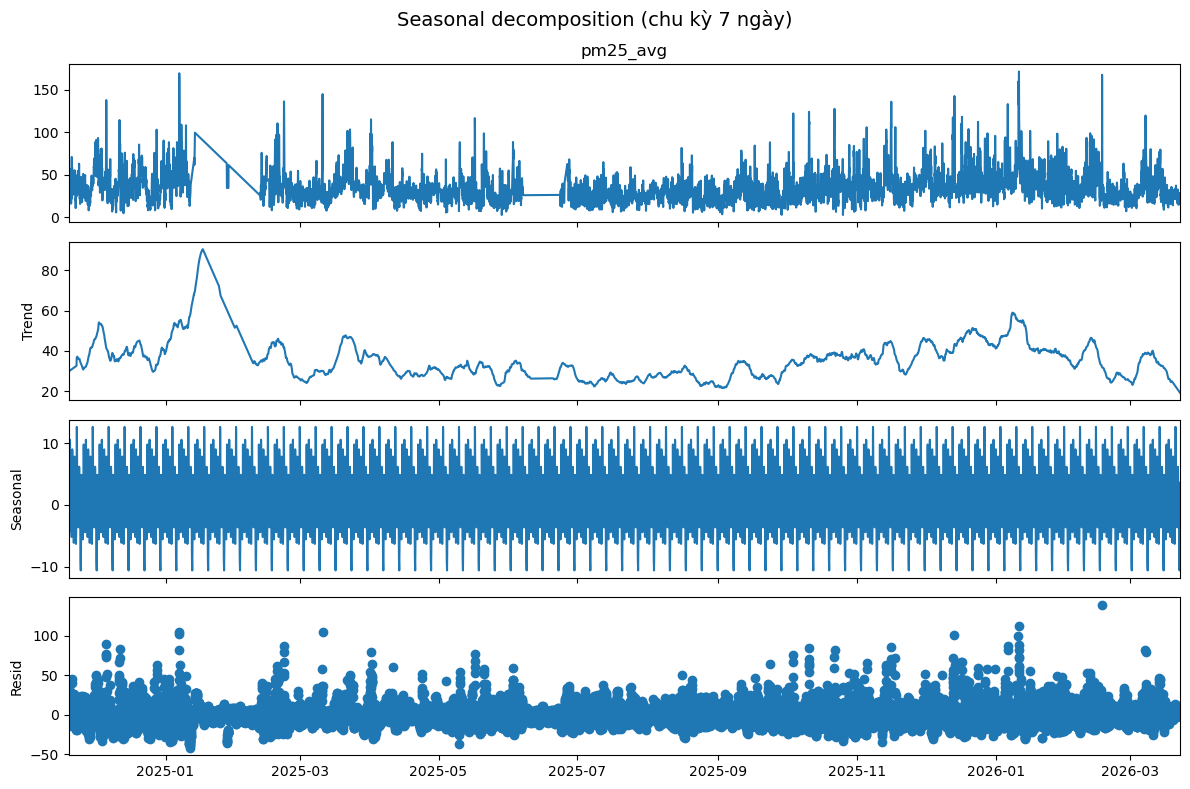

In [16]:
# @title Seasonal decomposition với chu kỳ 1 tuần (điền toàn bộ gap)
from statsmodels.tsa.seasonal import seasonal_decompose

decomp_series = (
    ts_hourly_full["pm25_avg"]
    .interpolate(method="time", limit=24 * 14, limit_direction="both")
    .fillna(ts_hourly_full["pm25_avg"].mean())
)

result = seasonal_decompose(
    decomp_series,
    model="additive",
    period=24 * 7,
    extrapolate_trend="freq",
)

fig = result.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Seasonal decomposition (chu kỳ 7 ngày)", fontsize=14)
plt.tight_layout()
plt.show()

### Nhận xét seasonal decomposition (chu kỳ 7 ngày)
- Thành phần **Trend** xác nhận đỉnh lớn vào cuối 2024–đầu 2025 (~80 µg/m³) và tăng trở lại vào cuối 2025–đầu 2026; giữa năm 2025 trend hạ xuống ~25–30 µg/m³ đúng mùa mưa.  
- **Seasonal** có biên độ khoảng ±8 µg/m³ và lặp đều 24 giờ, thể hiện cycle ngày/đêm rõ rệt: ban đêm PM2.5 cao hơn ngày. Điều này hỗ trợ việc tạo đặc trưng `hour`/`sin-cos`.  
- **Residual** cho thấy các spike dư thừa >80 µg/m³ tập trung vào giai đoạn đầu năm 2025 và đầu 2026; đây là những sự kiện cần mô hình giải thích bằng biến thời tiết hoặc xử lý outlier khi dự báo.

## c. ACF & PACF (đánh giá tự tương quan)
- Sử dụng chuỗi PM2.5 đã nội suy để đảm bảo không bị `NaN`.
- Vẽ ACF và PACF đến 72 giờ (~3 ngày) nhằm xác định các lag quan trọng cho feature lag/ mô hình ARIMA.

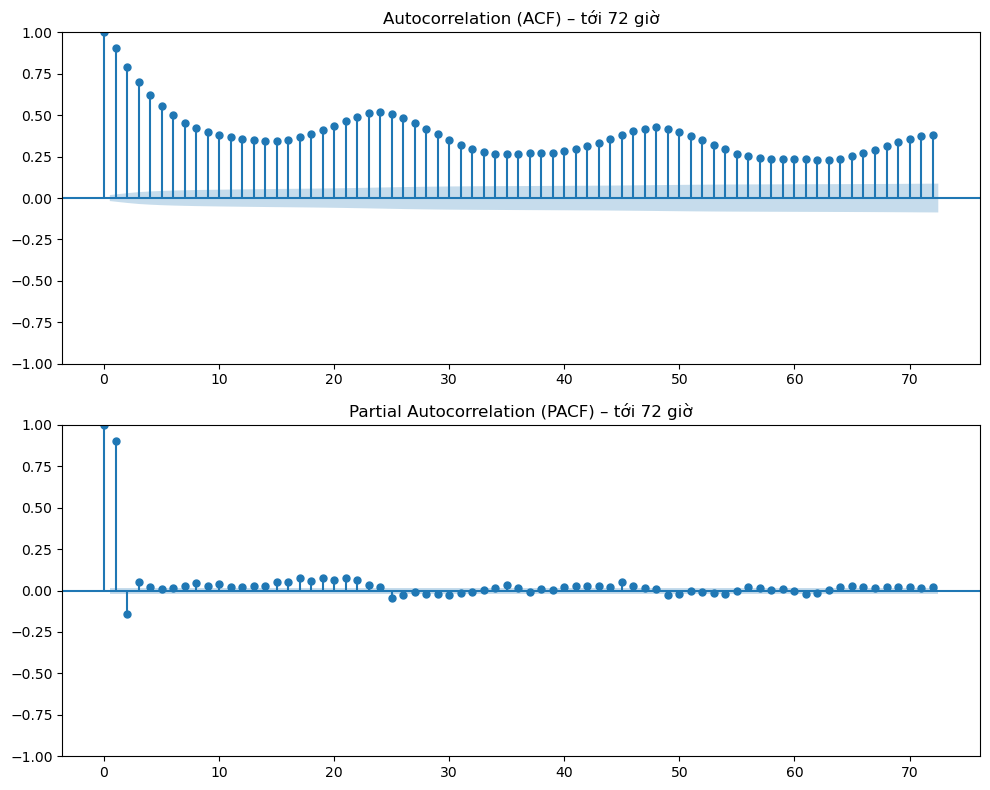

In [17]:
# @title Vẽ ACF & PACF tới 72 giờ
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

acf_series = (
    ts_hourly_full["pm25_avg"]
    .interpolate(method="time", limit=24 * 14, limit_direction="both")
    .fillna(ts_hourly_full["pm25_avg"].mean())
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(acf_series, lags=72, ax=axes[0])
axes[0].set_title("Autocorrelation (ACF) – tới 72 giờ")
plot_pacf(acf_series, lags=72, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation (PACF) – tới 72 giờ")
plt.tight_layout()
plt.show()

### Nhận xét ACF & PACF
- ACF giảm chậm, dao động tuần hoàn với chu kỳ 24 giờ (điểm uốn quanh lag 24, 48, 72), chứng tỏ chuỗi có tính mùa theo ngày rõ ràng và vẫn còn autocorrelation dài hạn → cần thêm các lag 24k trong feature engineering.  
- PACF nổi bật ở lag 1 và 2, sau đó nhanh chóng nằm trong vùng tin cậy; điều này gợi ý phần tự hồi quy ngắn hạn chủ yếu dựa vào 1–2 giờ gần nhất (giá trị lag dài đóng góp thông qua seasonal component).  
- ACF chưa cắt về 0 cho lag < 24 nên chuỗi chưa dừng; ta sẽ kiểm tra kỹ hơn bằng ADF/KPSS và cân nhắc differencing (đặc biệt seasonal differencing với chu kỳ 24 giờ).

## d. Kiểm định tính dừng (ADF & KPSS)
- Dùng chuỗi PM2.5 đã nội suy đầy đủ để tránh `NaN`.
- ADF kiểm tra giả thuyết có đơn vị gốc (H₀: chuỗi không dừng), KPSS kiểm tra ngược lại (H₀: chuỗi dừng theo trend); so sánh p-value để ra kết luận.

In [28]:
# !pip install statsmodels

In [ ]:
# @title Augmented Dickey-Fuller & KPSS tests
from statsmodels.tsa.stattools import adfuller, kpss

stationary_series = (
    ts_hourly_full["pm25_avg"]
    .interpolate(method="time", limit=24 * 14, limit_direction="both")
    .fillna(ts_hourly_full["pm25_avg"].mean())
)

adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, _ = adfuller(stationary_series, autolag="AIC")
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(stationary_series, regression="ct", nlags="auto")

print("=== Augmented Dickey-Fuller (ADF) ===")
print(f"Statistic: {adf_stat:.3f}, p-value: {adf_p:.4f}, used lags: {adf_lags}, obs: {adf_nobs}")
print("Critical values:")
for k, v in adf_crit.items():
    print(f"  {k}: {v:.3f}")

print("\n=== KPSS (trend stationarity) ===")
print(f"Statistic: {kpss_stat:.3f}, p-value: {kpss_p:.4f}, used lags: {kpss_lags}")
print("Critical values:")
for k, v in kpss_crit.items():
    print(f"  {k}: {v:.3f}")

### Nhận xét kiểm định ADF & KPSS
- **ADF**: statistic = -8.138 < các ngưỡng tới hạn và p-value ~0 ⇒ bác bỏ H₀ (có đơn vị gốc). Nghĩa là với phép kiểm này, chuỗi sau nội suy **được xem là dừng**.  
- **KPSS**: statistic = 1.271 > ngưỡng 1% (0.216) và p-value ≈ 0.01 ⇒ bác bỏ H₀ (chuỗi dừng theo trend). Theo KPSS, chuỗi **không dừng** vì vẫn tồn tại trend rõ rệt.  
- Hai kiểm định đưa ra kết luận trái chiều (thường xảy ra khi chuỗi có trend nhưng đã được làm mượt một phần). Điều này cho thấy cần **differencing** (đặc biệt seasonal differencing chu kỳ 24h hoặc trend differencing) trước khi dùng các mô hình ARIMA/VAR, hoặc đưa trend component vào mô hình học máy để hấp thụ phần không dừng.

---

## 8. IMPUTE MISSING VALUES: Chiến lược nội suy PM2.5 đa tầng
- **Resample liên tục:** bắt đầu từ `ts_hourly_full`, sao chép sang `ts_hourly_strategy` và giữ cờ `fill_method` để biết mỗi điểm được lấp bằng cách nào.  
- **Bước 1 – Interpolate theo thời gian (≤24h):** dùng `Series.interpolate(method="time", limit=24, limit_direction="both")` để lấp các gap ngắn liên tiếp.  
- **Bước 2 – Median theo giờ trong ngày:** những điểm còn thiếu được thay bằng median của cùng giờ (0–23) nhằm bảo toàn pattern ngày/đêm.  
- **Bước 3 – Rolling median 7 ngày:** áp dụng `rolling(window=24*7, center=True).median()` cho các đoạn dài hơn để giữ xu hướng tuần.  
- **Bước 4 – Global median fallback:** điểm nào vẫn thiếu thì điền bằng median toàn chuỗi để đảm bảo không còn `NaN`.  
- **Kết quả:** ghi log số điểm lấp ở từng bước và join cột `pm25_filled`, `fill_method` trở lại bảng `merged` để dùng cho modeling.

In [19]:
# @title Nội suy đa tầng cho PM2.5
import numpy as np
import pandas as pd

ts_hourly_strategy = ts_hourly_full.copy()
ts_hourly_strategy["pm25_filled"] = ts_hourly_strategy["pm25_avg"]
ts_hourly_strategy["fill_method"] = np.where(
    ts_hourly_strategy["pm25_avg"].isna(), "missing", "original"
)

fill_stats = []
def log_step(step_name, before_mask):
    after_mask = ts_hourly_strategy["pm25_filled"].isna()
    filled = int((before_mask & ~after_mask).sum())
    fill_stats.append({
        "step": step_name,
        "filled_points": filled,
        "remaining_missing": int(after_mask.sum()),
    })
    if filled > 0:
        ts_hourly_strategy.loc[before_mask & ~after_mask, "fill_method"] = step_name

initial_missing = ts_hourly_strategy["pm25_filled"].isna().sum()
print(f"Số giờ thiếu ban đầu: {initial_missing}")

# B1: Linear interpolation cho gap <=24h
before = ts_hourly_strategy["pm25_filled"].isna()
ts_hourly_strategy["pm25_filled"] = ts_hourly_strategy["pm25_filled"].interpolate(
    method="time", limit=24, limit_direction="both"
)
log_step("interp_time_<=24h", before)

# B2: Median theo giờ trong ngày
before = ts_hourly_strategy["pm25_filled"].isna()
hourly_median = (
    ts_hourly_strategy.groupby(ts_hourly_strategy.index.hour)["pm25_filled"]
    .transform("median")
)
ts_hourly_strategy.loc[before, "pm25_filled"] = hourly_median[before]
log_step("median_theo_gio", before)

# B3: Rolling median 7 ngày
before = ts_hourly_strategy["pm25_filled"].isna()
rolling_median = ts_hourly_strategy["pm25_filled"].rolling(
    window=24 * 7, min_periods=1, center=True
).median()
ts_hourly_strategy.loc[before, "pm25_filled"] = rolling_median[before]
log_step("rolling_median_7d", before)

# B4: Global median fallback
before = ts_hourly_strategy["pm25_filled"].isna()
global_med = ts_hourly_strategy["pm25_filled"].median()
ts_hourly_strategy.loc[before, "pm25_filled"] = global_med
log_step("global_median", before)

fill_report = pd.DataFrame(fill_stats)
print("\nTổng kết từng bước:")
display(fill_report)

print(f"Tổng số giờ còn thiếu sau khi nội suy: {ts_hourly_strategy['pm25_filled'].isna().sum()}")

# Merge cột mới vào bảng merged để sử dụng cho modeling
merged_filled = (
    merged
    .set_index("datetime")
    .join(ts_hourly_strategy[["pm25_filled", "fill_method"]], how="left")
    .reset_index()
)

print(f"Dataset sau khi thêm pm25_filled: {merged_filled.shape}")
merged_filled.head()

Số giờ thiếu ban đầu: 1317

Tổng kết từng bước:


,step,filled_points,remaining_missing
0,interp_time_<=24h,330,987
1,median_theo_gio,987,0
2,rolling_median_7d,0,0
3,global_median,0,0


Tổng số giờ còn thiếu sau khi nội suy: 0
Dataset sau khi thêm pm25_filled: (10409, 28)


,datetime,pm25_avg,pm25_min,pm25_max,pm25_median,coverage_pct,is_pm25_missing,temperature_2m,relative_humidity_2m,precipitation,...,day,hour,weekday,is_weekend,month_sin,month_cos,hour_sin,hour_cos,pm25_filled,fill_method
0,2024-11-19 10:00:00+00:00,29.139999,29.139999,29.139999,29.139999,100.0,False,32.0,55,0.0,...,19,10,1,0,-0.5,0.866025,5.000000e-01,-0.866025,29.139999,original
1,2024-11-19 11:00:00+00:00,29.150000,29.150000,29.150000,29.150000,100.0,False,30.9,59,0.1,...,19,11,1,0,-0.5,0.866025,2.588190e-01,-0.965926,29.150000,original
2,2024-11-19 12:00:00+00:00,31.783333,31.783333,31.783333,31.783333,100.0,False,29.3,68,0.0,...,19,12,1,0,-0.5,0.866025,1.224647e-16,-1.000000,31.783333,original
3,2024-11-19 13:00:00+00:00,30.950000,30.950000,30.950000,30.950000,100.0,False,26.6,77,0.2,...,19,13,1,0,-0.5,0.866025,-2.588190e-01,-0.965926,30.950000,original
4,2024-11-19 14:00:00+00:00,30.216667,30.216667,30.216667,30.216667,100.0,False,26.6,79,0.1,...,19,14,1,0,-0.5,0.866025,-5.000000e-01,-0.866025,30.216667,original


In [20]:
# @title Lưu dataset đã xử lý missing
processed_path = PROCESSED_DIR / "pm25_weather_filled.csv"
merged_filled.to_csv(processed_path, index=False)
print(f"Đã lưu dataset đã nội suy PM2.5: {processed_path}")
print(f"Shape: {merged_filled.shape}")

Đã lưu dataset đã nội suy PM2.5: D:\pm25-hcmc\data\processed\pm25_weather_filled.csv
Shape: (10409, 28)


---

## Tóm tắt tiến trình EDA & xử lý PM2.5
1. **Khởi tạo & đọc dữ liệu:** thiết lập đường dẫn, load `pm25_sensor_11357424.csv` và `weather_openmeteo.csv`, chuẩn hóa cột thời gian, kiểm tra kích thước, thống kê nhanh và tỷ lệ missing ban đầu.  
2. **EDA cơ bản:** boxplot outlier, mô tả phân phối thời tiết, loại bỏ giá trị PM2.5 bất thường (>500 hoặc âm), merge với thời tiết, tạo thêm đặc trưng thời gian (year/month/day/hour, sin–cos), lưu dataset ra `data/processed/pm25_weather_merged.csv`.  
3. **Phân tích thời gian nâng cao:**  
   - Resample tạo timeline liên tục, đánh dấu và thống kê gap dài nhất.  
   - Trực quan hóa missing theo tháng (bar severity) và heatmap tháng × giờ.  
   - Line plot toàn chuỗi + rolling mean 7 ngày, seasonal decomposition chu kỳ 7 ngày.  
   - Vẽ ACF/PACF tới 72 giờ và chạy kiểm định ADF/KPSS để đánh giá tính dừng.  
4. **Chiến lược xử lý missing:** áp dụng nội suy đa tầng (linear ≤24h → median theo giờ → rolling median 7 ngày → global median), ghi lại số điểm lấp ở mỗi bước và bổ sung cột `pm25_filled` cùng `fill_method` vào bảng hợp nhất cho giai đoạn feature engineering / modeling tiếp theo.